# Multimodal Machine Learning on Human Brain Spatial Transcriptomics

**Training School – hands-on mini-project**

> **Tutorial:** Predicting cortical region identity from spatial **gene expression** and
> **metabolic flux** (generated by scFEA) using Early and Late Fusion strategies,
> with SHAP explainability and spatial validation on the tissue.

---

## Overview

This notebook walks through an end-to-end machine-learning pipeline on spatial transcriptomics data.
We combine two modalities on the same tissue spots, **gene expression** and
**metabolic flux**, to predict which part of the cortex each spot belongs to. We then interpret
the model to find which genes and metabolic reactions drive the prediction, and validate those
findings by plotting them back onto the tissue.

The human cortex is layered: six neuronal layers (L1–L6) sit above the white matter (WM).
These regions differ in cell type, connectivity and energy demand, and the dataset comes with a
manually expert annotation, so we have a trustworthy ground truth.

| Modality | What it is | Source |
|----------|-----------|--------|
| **Gene expression** | 1,000 highly variable genes per spot | 10x Visium (measured) |
| **Metabolic flux** | 168 metabolic module flux rates per spot | scFEA (estimated) |
| **Label** | Superficial / Deep / White matter | Expert annotation |

**Dataset:** LIBD Human DLPFC Visium — 12 tissue sections from 3 donors, 12,000 spots
(*Maynard et al., Nature Neuroscience 2021*).

This tutorial builds on:

- **Metabolic Features Generation**
  *Generate metabolic module flux rates for single-cell transcriptomics using scFEA (Alghamdi et al., 2021).*
  Github: https://github.com/changwn/scFEA

- **Dataset**
  *Maynard et al., 2021. Transcriptome-scale spatial gene expression in the human dorsolateral prefrontal cortex. Nature Neuroscience 24:425–436.*
  Github: https://github.com/LieberInstitute/HumanPilot

## Prerequisites

Installing packages and downloading dataset:

Run **Section 1** to install packages and **Section 2** to download the data to your machine.

## Your tasks

Cells marked **`### YOUR TURN`** are for you to complete or modify. Everything else runs as-is.

## 1. Setup & Imports

In [ ]:
# Package installation: Uncomment and run the following line once. 
# !pip install scanpy scikit-learn shap seaborn matplotlib pandas numpy

In [8]:
# Core data & visualisation 
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")

# Scikit-learn: preprocessing, models, evaluation 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)

# Explainability 
import shap

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup complete.")

Setup complete.


## 2. Data Loading

Three analysis-ready tables. Each row is a **tissue spot**, and all three share the same spot
identifiers so they line up row for row.

| File | Shape | Contents |
|------|-------|----------|
| `dlpfc_gene_expression.csv` | 12,000 × 1,000 | log-normalised expression, highly variable genes |
| `dlpfc_flux.csv` | 12,000 × 168 | scFEA metabolic module flux rates |
| `dlpfc_metadata.csv` | 12,000 × 7 | layer label, donor, section, spatial coordinates |

In [ ]:
# Download the workshop data (skips any file that is already present)
import urllib.request

# ── Organisers: replace with the URL where the three CSV files are hosted ──
DATA_URL = "https://raw.githubusercontent.com/kaveh8/workshop_Net4Brain/main/workshop_data"
FILES = ["dlpfc_gene_expression.csv.gz", "dlpfc_flux.csv.gz", "dlpfc_metadata.csv.gz"]

os.makedirs("workshop_data", exist_ok=True)
for f in FILES:
    dest = os.path.join("workshop_data", f)
    if not os.path.exists(dest):
        print(f"downloading {f} ...")
        urllib.request.urlretrieve(DATA_URL + f, dest)
    print(f"{f:30s} {os.path.getsize(dest)/1e6:6.1f} MB")

# To rebuild these tables from the raw 10x files instead, see the Appendix.

downloading dlpfc_gene_expression.csv.gz ...
dlpfc_gene_expression.csv.gz      2.7 MB
downloading dlpfc_flux.csv.gz ...
dlpfc_flux.csv.gz                 8.6 MB
downloading dlpfc_metadata.csv.gz ...
dlpfc_metadata.csv.gz             0.2 MB


In [11]:
path = "workshop_data/"
# extract gz files to path folder
import gzip

for f in FILES:
    with gzip.open(path + f, 'rb') as f_in:
        with open(path + f.replace('.gz', ''), 'wb') as f_out:
            f_out.write(f_in.read())

df_gene = pd.read_csv(path + "dlpfc_gene_expression.csv", index_col=0)
df_flux = pd.read_csv(path + "dlpfc_flux.csv",            index_col=0)
df_meta = pd.read_csv(path + "dlpfc_metadata.csv",        index_col=0)

# Make sure all three tables describe the same spots, in the same order
common = df_gene.index.intersection(df_flux.index).intersection(df_meta.index)
df_gene, df_flux, df_meta = df_gene.loc[common], df_flux.loc[common], df_meta.loc[common]

print(f"Gene expression : {df_gene.shape[0]:>6,} spots x {df_gene.shape[1]:>4} genes")
print(f"Metabolic flux  : {df_flux.shape[0]:>6,} spots x {df_flux.shape[1]:>4} modules")
print(f"Metadata        : {df_meta.shape[0]:>6,} spots x {df_meta.shape[1]:>4} columns")

Gene expression : 12,000 spots x 1000 genes
Metabolic flux  : 12,000 spots x  168 modules
Metadata        : 12,000 spots x    7 columns


In [13]:
print("Transcriptomic data: first 5 rows in transcriptomic modality")
df_gene.iloc[:5, ]

Transcriptomic data: first 5 rows in transcriptomic modality


,SAMD11,ISG15,VWA1,AL031847.1,VAMP3,RBP7,CORT,CASZ1,AGTRAP,DDI2,...,FBLN1,MIRLET7BHG,PLXNB2,SBF1,ADAMTS1,TFF3,TFF1,COL6A1,COL6A2,S100B
151507_AAACAAGTATCTCCCA-1,0.0,1.3772,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.3772,0.0,0.00,0.0,0.0,0.0000,1.9355,1.9355,0.0,0.0000
151507_AAACAATCTACTAGCA-1,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0,2.12,0.0,0.0,0.0000,0.0000,0.0000,0.0,3.6285
151507_AAACACCAATAACTGC-1,0.0,1.5226,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.00,0.0,0.0,0.0000,0.0000,0.0000,0.0,3.2615
151507_AAACAGCTTTCAGAAG-1,0.0,1.6917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.00,0.0,0.0,1.6917,0.0000,0.0000,0.0,1.6917
151507_AAACAGGGTCTATATT-1,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.00,0.0,0.0,1.3808,0.0000,0.0000,0.0,1.9396


In [14]:
print("Metabolic data: first 5 rows")
df_flux.iloc[:5, ]

Metabolic data: first 5 rows


,M_1,M_2,M_3,M_4,M_5,M_6,M_7,M_8,M_9,M_10,...,M_162,M_163,M_164,M_165,M_166,M_167,M_168,M_169,M_170,M_171
151507_AAACAAGTATCTCCCA-1,-0.000141,0.039663,0.060288,0.005242,0.000057,0.015459,0.000008,-0.000768,-0.000086,0.013663,...,0.003318,0.000009,-0.000003,0.013659,0.000032,0.022994,0.027953,2.328306e-10,0.005776,0.002843
151507_AAACAATCTACTAGCA-1,-0.000261,0.016715,0.017314,0.000195,0.000035,0.008592,0.000008,-0.001272,-0.000143,0.013086,...,0.003155,0.000009,-0.000003,0.010823,0.000031,0.019291,0.023094,0.000000e+00,0.005774,0.002745
151507_AAACACCAATAACTGC-1,-0.000247,0.018629,0.023479,0.000285,0.000037,0.008789,0.000008,-0.001162,-0.000138,0.013166,...,0.003230,0.000009,-0.000003,0.011185,0.000032,0.025227,0.024341,3.492460e-10,0.005774,0.002752
151507_AAACAGCTTTCAGAAG-1,-0.000230,0.026383,0.031251,0.001113,0.000042,0.009498,0.000008,-0.001124,-0.000131,0.013496,...,0.003232,0.000009,-0.000003,0.011901,0.000033,0.020314,0.024706,0.000000e+00,0.005774,0.002782
151507_AAACAGGGTCTATATT-1,-0.000033,0.067712,0.102772,0.034055,0.000090,0.023890,0.000009,-0.000450,-0.000035,0.016140,...,0.003493,0.000009,-0.000002,0.017311,0.000035,0.027819,0.032880,9.080395e-09,0.005776,0.003033


In [15]:
print("Metadata: first 5 rows")
df_meta.head(5)

Metadata: first 5 rows


,sample_id,donor,layer,array_row,array_col,pxl_row,pxl_col
151507_AAACAAGTATCTCCCA-1,151507,Br5292,L3,50,102,8520,9178
151507_AAACAATCTACTAGCA-1,151507,Br5292,L1,3,43,2878,5133
151507_AAACACCAATAACTGC-1,151507,Br5292,WM,59,19,9581,3462
151507_AAACAGCTTTCAGAAG-1,151507,Br5292,L6,43,9,7663,2779
151507_AAACAGGGTCTATATT-1,151507,Br5292,L6,47,13,8143,3053


## 3. Exploratory Data Analysis

Before modelling, look at the data. How many spots per layer? Are the classes balanced?
Do the two modalities have comparable scales?

In [16]:
LAYER_ORDER = ["L1", "L2", "L3", "L4", "L5", "L6", "WM"]

print("Expert layer annotation:")
print(df_meta["layer"].value_counts().reindex(LAYER_ORDER).to_string())
print(f"\nDonors  : {sorted(df_meta['donor'].unique())}")
print(f"Sections: {df_meta['sample_id'].nunique()}")

Expert layer annotation:
layer
L1    1254
L2     689
L3    4458
L4     896
L5    1892
L6    1618
WM    1193

Donors  : ['Br5292', 'Br5595', 'Br8100']
Sections: 12


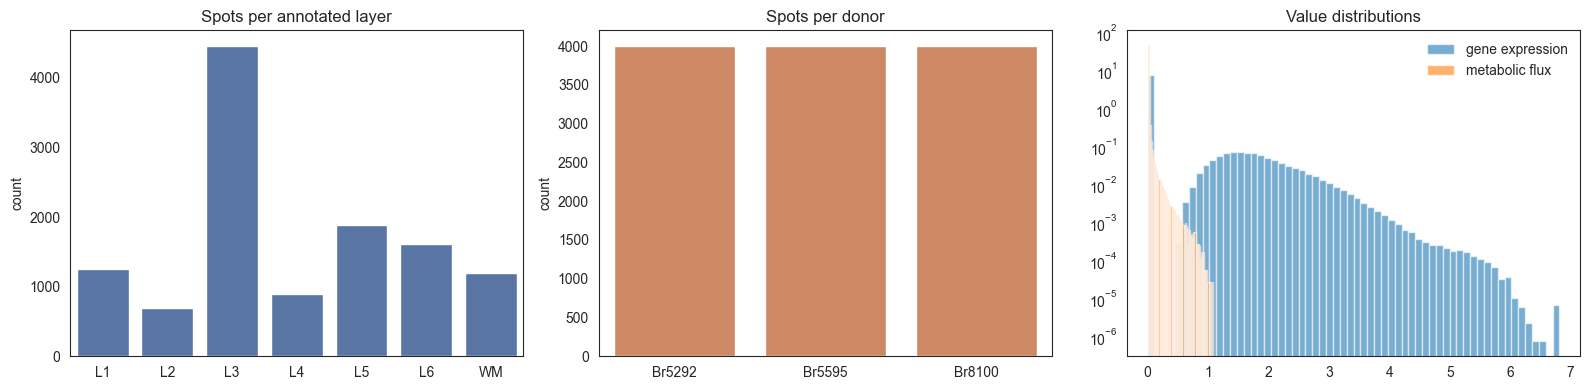

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df_meta, x="layer", order=LAYER_ORDER, ax=axes[0], color="#4C72B0")
axes[0].set_title("Spots per annotated layer"); axes[0].set_xlabel("")

sns.countplot(data=df_meta, x="donor", ax=axes[1], color="#DD8452")
axes[1].set_title("Spots per donor"); axes[1].set_xlabel("")

axes[2].hist(df_gene.values.ravel(), bins=60, alpha=.6, label="gene expression", density=True)
axes[2].hist(df_flux.values.ravel(), bins=60, alpha=.6, label="metabolic flux", density=True)
axes[2].set_yscale("log"); axes[2].set_title("Value distributions"); axes[2].legend(frameon=False)

plt.tight_layout(); plt.show()

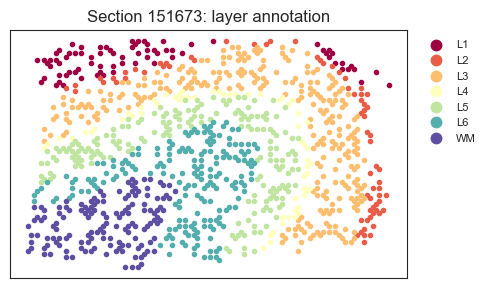

In [19]:
# What does the tissue actually look like? Plot the annotation for one section.
SECTION = "151673"
sel = df_meta["sample_id"].astype(str) == SECTION

fig, ax = plt.subplots(figsize=(5, 5))
for i, lay in enumerate(LAYER_ORDER):
    mm = sel & (df_meta["layer"] == lay)
    ax.scatter(df_meta.loc[mm, "array_col"], df_meta.loc[mm, "array_row"],
               s=9, label=lay, color=plt.cm.Spectral(i / 6))
ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Section {SECTION}: layer annotation")
ax.legend(markerscale=2.5, fontsize=8, frameon=False, bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

### 🔬 YOUR TURN — explore the data

Pick **one** thing to look at and produce a plot. Some ideas:

* How does a known layer-marker gene behave across layers? (`MBP` marks white matter, `PCP4` marks L5)
* Which metabolic module varies most between layers?
* Do sections from different donors look similar, or is there a visible batch effect?

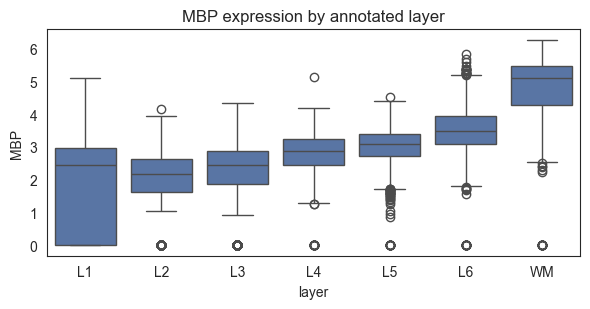

In [20]:
### YOUR TURN ###
# Example to get you started — replace with your own exploration:
gene = "MBP"          # <-- change this gene
if gene in df_gene.columns:
    fig, ax = plt.subplots(figsize=(6, 3.2))
    sns.boxplot(x=df_meta["layer"], y=df_gene[gene], order=LAYER_ORDER, ax=ax, color="#4C72B0")
    ax.set_title(f"{gene} expression by annotated layer")
    plt.tight_layout(); plt.show()
else:
    print(f"{gene} is not in the highly variable gene set. Try another.")

# Your code here:


## 4. Defining the Prediction Target

Predicting all **seven** layers at once is hard: L2 and L3 are transcriptionally very similar,
and the class sizes are badly unbalanced. So we start with a coarser but still biologically
meaningful target:

| Group | Layers | Biology |
|-------|--------|---------|
| **Superficial** | L1–L3 | mostly local cortico-cortical connections |
| **Deep** | L4–L6 | thalamic input and long-range output |
| **White matter** | WM | myelinated axons, few neuronal cell bodies |

You will get the chance to attempt the full 7-class problem later — it is a good stretch task.

In [21]:
LAYER_GROUP = {"L1": "Superficial", "L2": "Superficial", "L3": "Superficial",
               "L4": "Deep",        "L5": "Deep",        "L6": "Deep",
               "WM": "White matter"}

df_meta["region"] = df_meta["layer"].map(LAYER_GROUP)

le = LabelEncoder()
y = le.fit_transform(df_meta["region"])
print("Classes:", dict(enumerate(le.classes_)))
print()
print(df_meta["region"].value_counts().to_string())

Classes: {0: 'Deep', 1: 'Superficial', 2: 'White matter'}

region
Superficial     6401
Deep            4406
White matter    1193


## 5. Using the Spatial Information

So far every spot has been treated as an independent sample; we have thrown away the fact that
this is *spatial* data. Neighbouring spots belong to the same layer, so averaging each spot with
its neighbours suppresses measurement noise while preserving the layer signal.

This is the single biggest improvement in the whole pipeline. We smooth **within each section**
only, so no information leaks between tissues.

In [23]:
def spatial_smooth(df, meta, k=12):
    """Average each spot with its k nearest neighbours, within its own section."""
    out = np.zeros_like(df.values, dtype=float)
    for s in meta["sample_id"].unique():
        idx = np.where(meta["sample_id"].values == s)[0]
        xy = meta.iloc[idx][["array_row", "array_col"]].values.astype(float)
        nn = NearestNeighbors(n_neighbors=min(k, len(idx))).fit(xy)
        _, ind = nn.kneighbors(xy)
        out[idx] = df.values[idx][ind].mean(axis=1)
    return pd.DataFrame(out, index=df.index, columns=df.columns)

K_NEIGHBOURS = 12          # <-- try 6, 12, 24 and see what happens to accuracy

df_gene_sm = spatial_smooth(df_gene, df_meta, k=K_NEIGHBOURS)
df_flux_sm = spatial_smooth(df_flux, df_meta, k=K_NEIGHBOURS)
print(f"Smoothed both modalities over {K_NEIGHBOURS} nearest neighbours within each section.")

Smoothed both modalities over 12 nearest neighbours within each section.


## 6. Feature Preparation & Train/Test Split

**Important:** we split by **donor**, not randomly. Spots from the same section are physically
adjacent and highly correlated — a random split would put near-duplicate spots in both train and
test and give a flattering, meaningless accuracy. Holding out an entire donor asks the honest
question: *does this generalise to a new brain?*

In [24]:
# Separate feature matrices and target ────────────────────
X_gene = df_gene_sm.copy()      # Gene expression features (spatially smoothed)
X_flux = df_flux_sm.copy()      # Metabolic flux features  (spatially smoothed)

# Split by donor: train on two brains, test on the third
TEST_DONOR = "Br8100"           # <-- try Br5292 or Br5595 as well
train_mask = (df_meta["donor"] != TEST_DONOR).values
test_mask  = ~train_mask

y_train, y_test = y[train_mask], y[test_mask]
print(f"Train: {train_mask.sum():,} spots (donors {sorted(df_meta.loc[train_mask, 'donor'].unique())})")
print(f"Test : {test_mask.sum():,} spots (donor  {TEST_DONOR})")

Train: 8,000 spots (donors ['Br5292', 'Br5595'])
Test : 4,000 spots (donor  Br8100)


In [25]:
# Scale each modality separately — fit on TRAIN only, then apply to test
sc_gene, sc_flux = StandardScaler(), StandardScaler()

X_gene_train = sc_gene.fit_transform(X_gene[train_mask])
X_gene_test  = sc_gene.transform(X_gene[test_mask])

X_flux_train = sc_flux.fit_transform(X_flux[train_mask])
X_flux_test  = sc_flux.transform(X_flux[test_mask])

print(f"Gene : train {X_gene_train.shape}  test {X_gene_test.shape}")
print(f"Flux : train {X_flux_train.shape}  test {X_flux_test.shape}")

Gene : train (8000, 1000)  test (4000, 1000)
Flux : train (8000, 168)  test (4000, 168)


## 7. Early Fusion Modelling

**Early fusion** = glue the two feature tables side by side into one wide matrix, then train a
single model on the combined features. The model is free to find interactions between a gene and
a metabolic module.

In [26]:
# Concatenate modalities horizontally (early fusion) ──────
X_early_train = np.hstack((X_gene_train, X_flux_train))
X_early_test  = np.hstack((X_gene_test,  X_flux_test))

feature_names = list(X_gene.columns) + list(X_flux.columns)
print(f"Early fusion feature space: {X_early_train.shape[1]} features "
      f"({X_gene.shape[1]} genes + {X_flux.shape[1]} flux modules)")

Early fusion feature space: 1168 features (1000 genes + 168 flux modules)


**Train a classifier on the combined feature space**

You can try to change the hyperparameters for the random forest (`n_estimators`, `max_depth`,
`min_samples_split`) and see how the scores move.

In [27]:
rf_early = RandomForestClassifier(n_estimators=200, max_depth=12,
                                  min_samples_split=2, n_jobs=-1,
                                  random_state=RANDOM_STATE)
rf_early.fit(X_early_train, y_train)
y_pred_early = rf_early.predict(X_early_test)

print("── Early fusion (genes + flux) ──")
print(f"Accuracy          : {accuracy_score(y_test, y_pred_early):.3f}")
print(f"Balanced accuracy : {balanced_accuracy_score(y_test, y_pred_early):.3f}\n")
print(classification_report(y_test, y_pred_early, target_names=le.classes_, zero_division=0))

── Early fusion (genes + flux) ──
Accuracy          : 0.730
Balanced accuracy : 0.777

              precision    recall  f1-score   support

        Deep       0.63      0.89      0.74      1720
 Superficial       0.90      0.46      0.61      1628
White matter       0.86      0.98      0.92       652

    accuracy                           0.73      4000
   macro avg       0.80      0.78      0.75      4000
weighted avg       0.78      0.73      0.71      4000



**Does the second modality actually help?**

Always compare fusion against each modality alone. If genes alone do just as well, the flux
features are not adding information — and saying so is a perfectly good result.

Note the two metrics. **Accuracy** counts how many spots were right; **balanced accuracy**
averages the per-class recall. With unequal class sizes a model that ignores the smallest class
can still score well on accuracy, so balanced accuracy is the more honest number here.

In [28]:
results = {}
for name, Xtr, Xte in [("Genes only",   X_gene_train,  X_gene_test),
                       ("Flux only",    X_flux_train,  X_flux_test),
                       ("Early fusion", X_early_train, X_early_test)]:
    mdl = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1,
                                 random_state=RANDOM_STATE)
    mdl.fit(Xtr, y_train)
    p = mdl.predict(Xte)
    results[name] = {"Accuracy": accuracy_score(y_test, p),
                     "Balanced accuracy": balanced_accuracy_score(y_test, p)}

df_results = pd.DataFrame(results).T.round(3)
print(df_results.to_string())

              Accuracy  Balanced accuracy
Genes only       0.879              0.901
Flux only        0.505              0.515
Early fusion     0.730              0.777


**Does fusion always help?**

On the default split you should find that genes alone beat early fusion, because the flux
features are much weaker on their own and adding 168 noisy columns dilutes the 1,000 informative
ones. That is a real, publishable-style finding, not a bug in your code.

This is the single most important lesson in the notebook: **more modalities is not automatically
better.** Combining data only helps when the second modality carries information the first does
not. Part of your job in the presentation is to say *whether it helped here, and why or why not*.

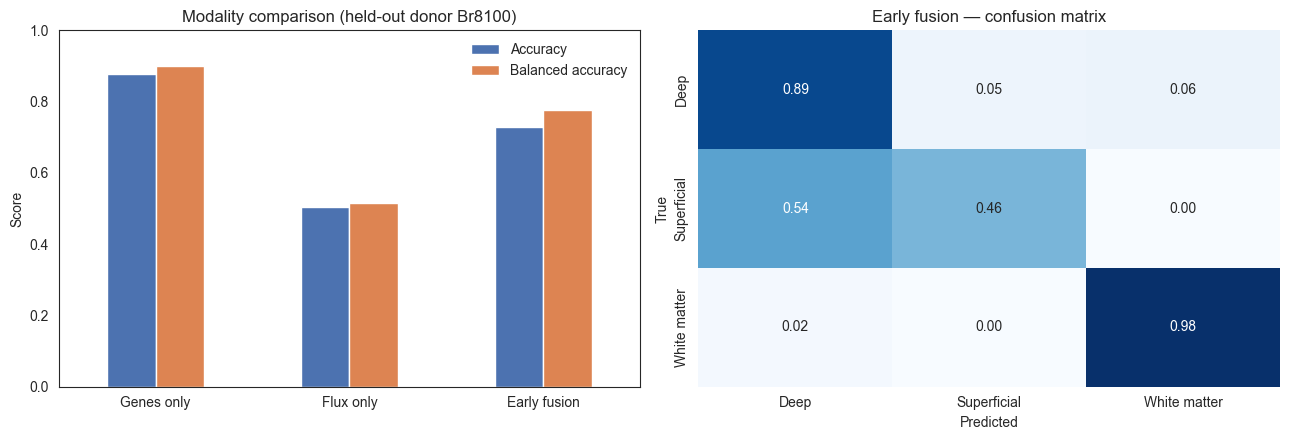

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df_results.plot.bar(ax=axes[0], rot=0, color=["#4C72B0", "#DD8452"])
axes[0].set_title(f"Modality comparison (held-out donor {TEST_DONOR})")
axes[0].set_ylabel("Score"); axes[0].set_ylim(0, 1); axes[0].legend(frameon=False)

cm = confusion_matrix(y_test, y_pred_early, normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title("Early fusion — confusion matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout(); plt.show()

### 🔬 YOUR TURN — try a different model

Replace the random forest with another classifier and compare. Suggestions:
`LogisticRegression(max_iter=1000)`, `sklearn.svm.LinearSVC()`,
`sklearn.ensemble.HistGradientBoostingClassifier()`, or a small `MLPClassifier`.

Report **both** accuracy and balanced accuracy — with three unequal classes they tell
different stories.

In [ ]:
### YOUR TURN ###
# my_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
# my_model.fit(X_early_train, y_train)
# my_pred = my_model.predict(X_early_test)
# print(f"Accuracy          : {accuracy_score(y_test, my_pred):.3f}")
# print(f"Balanced accuracy : {balanced_accuracy_score(y_test, my_pred):.3f}")

# Your code here:


## 8. SHAP Explainability

The model works — but *what is it using*? SHAP assigns every feature a contribution to every
prediction, so we can ask which genes and which metabolic modules separate the regions.

SHAP on a 1,168-feature forest is expensive, so we explain a random subsample of test spots.

In [30]:
# Explain a subsample of test spots (SHAP is computationally expensive)
N_EXPLAIN = 300
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(X_early_test.shape[0], size=min(N_EXPLAIN, X_early_test.shape[0]), replace=False)
X_explain = X_early_test[idx]

explainer = shap.TreeExplainer(rf_early)
shap_values = np.array(explainer.shap_values(X_explain, check_additivity=False))
print("SHAP values computed:", shap_values.shape, "(spots, features, classes)")

SHAP values computed: (300, 1168, 3) (spots, features, classes)


In [31]:
# Mean |SHAP| across spots and classes = overall feature importance
importance = (np.abs(shap_values).mean(axis=(0, 2)) if shap_values.ndim == 3
              else np.abs(shap_values).mean(axis=0))

shap_df = (pd.DataFrame({"feature": feature_names, "importance": importance})
             .assign(modality=lambda d: np.where(d["feature"].str.startswith("M_"),
                                                 "Metabolic flux", "Gene"))
             .sort_values("importance", ascending=False)
             .reset_index(drop=True))

print("Top 15 features overall:")
print(shap_df.head(15).to_string(index=False))

Top 15 features overall:
feature  importance       modality
    MBP    0.031663           Gene
   PLP1    0.026235           Gene
 CARTPT    0.018385           Gene
     TF    0.017113           Gene
   MOBP    0.017016           Gene
    CNP    0.012676           Gene
 CLDND1    0.009397           Gene
   ENC1    0.009013           Gene
   SPP1    0.007812           Gene
  CRYAB    0.006443           Gene
    MAG    0.005594           Gene
   M_87    0.005348 Metabolic flux
   GFAP    0.004931           Gene
SCGB2A2    0.004929           Gene
 CLDN11    0.004700           Gene


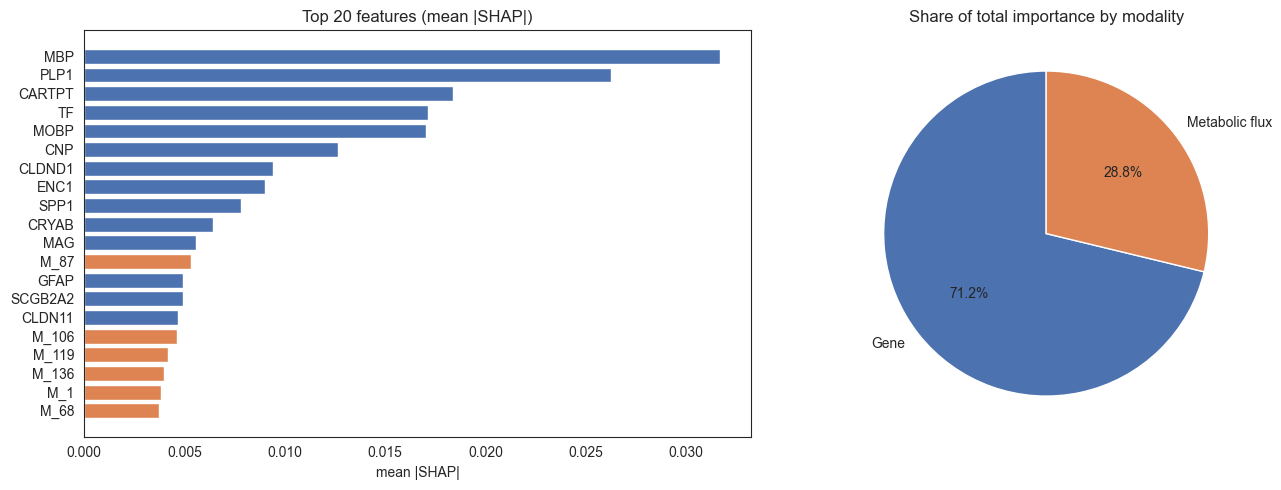

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top20 = shap_df.head(20).iloc[::-1]
axes[0].barh(top20["feature"], top20["importance"],
             color=top20["modality"].map({"Gene": "#4C72B0", "Metabolic flux": "#DD8452"}))
axes[0].set_title("Top 20 features (mean |SHAP|)"); axes[0].set_xlabel("mean |SHAP|")

share = shap_df.groupby("modality")["importance"].sum()
axes[1].pie(share, labels=share.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Share of total importance by modality")

plt.tight_layout(); plt.show()

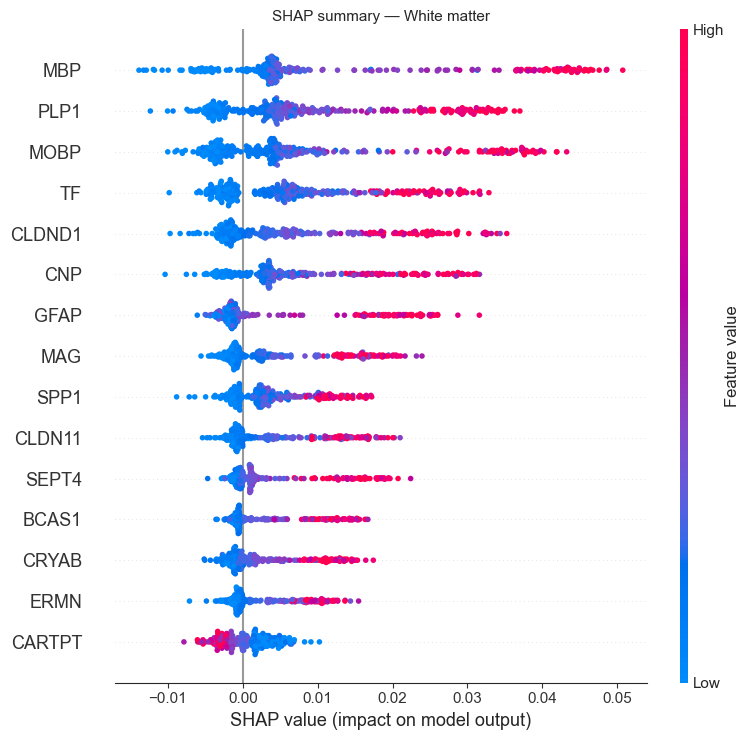

In [33]:
# A SHAP summary plot for one class shows the direction of each effect,
# not just its magnitude.
CLASS_TO_PLOT = "White matter"
ci = list(le.classes_).index(CLASS_TO_PLOT)

shap.summary_plot(shap_values[:, :, ci], X_explain,
                  feature_names=feature_names, max_display=15, show=False)
plt.title(f"SHAP summary — {CLASS_TO_PLOT}", fontsize=11)
plt.tight_layout(); plt.show()

In [34]:
# Which metabolic modules matter most? Map module IDs to their reactions.
mod_info = pd.read_csv("https://raw.githubusercontent.com/changwn/scFEA/master/"
                       "data/Human_M168_information.symbols.csv", index_col=0)
mod_info["reaction"] = (mod_info["Compound_IN_name"].astype(str) + " -> "
                        + mod_info["Compound_OUT_name"].astype(str))

top_flux = shap_df[shap_df["modality"] == "Metabolic flux"].head(10).copy()
top_flux["reaction"] = top_flux["feature"].map(mod_info["reaction"])
print("Top 10 metabolic modules:")
print(top_flux[["feature", "reaction", "importance"]].to_string(index=False))

Top 10 metabolic modules:
feature                                      reaction  importance
   M_87                   Pyrimidine_in -> Pyrimidine    0.005348
  M_106                Glucose -> Glucose-6-phosphate    0.004631
  M_119 Dolichyl phosphate -> (GlcNAc)4 (Man)3 (Asn)1    0.004171
  M_136                                    IMP -> AMP    0.003992
    M_1                                Glucose -> G6P    0.003866
   M_68              Proline -> Glyoxylate + pyruvate    0.003744
  M_115                 (E,E)-Farnesyl-PP -> Farnesal    0.003658
  M_143                           IMP -> Hypoxanthine    0.003321
   M_34                      Acetyl-CoA -> Fatty Acid    0.003207
  M_114        (E,E)-Farnesyl-PP -> Geranylgeranyl-PP    0.002797


### 🔬 YOUR TURN — interpret the SHAP results

Look up two or three of your top genes on [GeneCards](https://www.genecards.org) or the
[Human Protein Atlas](https://www.proteinatlas.org). Are they known markers for the region
the model assigned them to?

Then answer in your presentation: *does the model agree with what neuroscience already knows,
or is it using something unexpected?*

In [35]:
### YOUR TURN ###
# Check how your top genes actually behave across the layers.
# my_genes = shap_df[shap_df["modality"] == "Gene"].head(4)["feature"].tolist()
# fig, axes = plt.subplots(1, len(my_genes), figsize=(4*len(my_genes), 3))
# for ax, gname in zip(axes, my_genes):
#     sns.boxplot(x=df_meta["layer"], y=df_gene[gname], order=LAYER_ORDER, ax=ax, color="#4C72B0")
#     ax.set_title(gname); ax.set_xlabel(""); ax.set_ylabel("")
# plt.tight_layout(); plt.show()

# Your code here:


## 9. Spatial Validation

This is what makes spatial data special. A SHAP score is just a number — but here we can plot the
top features **back onto the tissue** and check whether they form a genuine anatomical gradient
or whether the model latched onto noise.

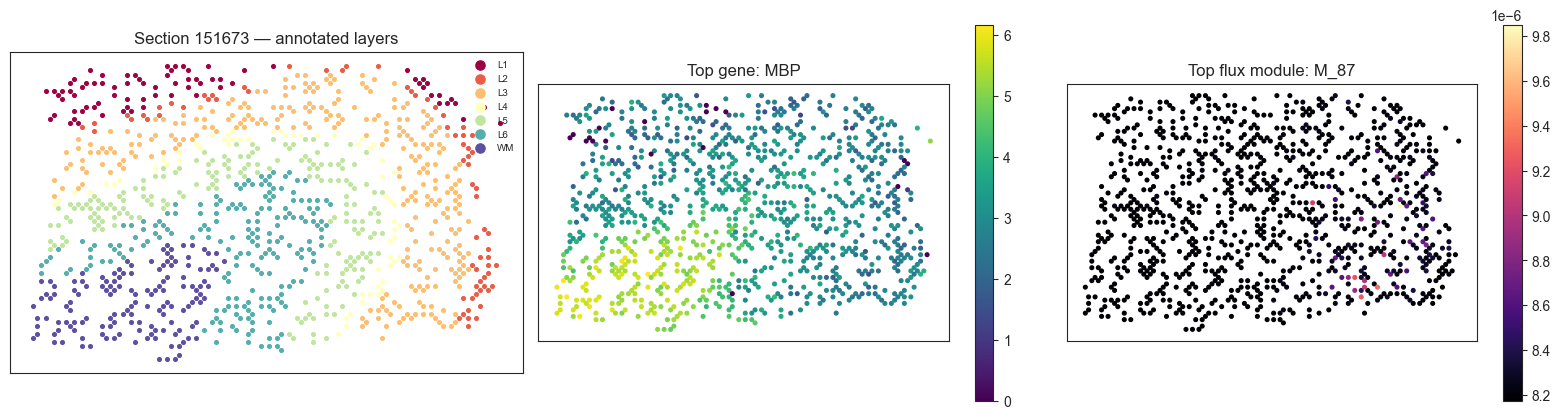

In [36]:
coords = df_meta.loc[sel, ["array_col", "array_row"]]
top_gene = shap_df[shap_df["modality"] == "Gene"].iloc[0]["feature"]
top_mod  = shap_df[shap_df["modality"] == "Metabolic flux"].iloc[0]["feature"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, lay in enumerate(LAYER_ORDER):
    mm = sel & (df_meta["layer"] == lay)
    axes[0].scatter(df_meta.loc[mm, "array_col"], df_meta.loc[mm, "array_row"],
                    s=7, label=lay, color=plt.cm.Spectral(i / 6))
axes[0].set_title(f"Section {SECTION} — annotated layers")
axes[0].legend(markerscale=2.5, fontsize=7, frameon=False, loc="upper right")

s2 = axes[1].scatter(coords["array_col"], coords["array_row"],
                     c=df_gene.loc[sel, top_gene], s=7, cmap="viridis")
axes[1].set_title(f"Top gene: {top_gene}"); plt.colorbar(s2, ax=axes[1], shrink=.8)

s3 = axes[2].scatter(coords["array_col"], coords["array_row"],
                     c=df_flux.loc[sel, top_mod], s=7, cmap="magma")
axes[2].set_title(f"Top flux module: {top_mod}"); plt.colorbar(s3, ax=axes[2], shrink=.8)

for ax in axes:
    ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

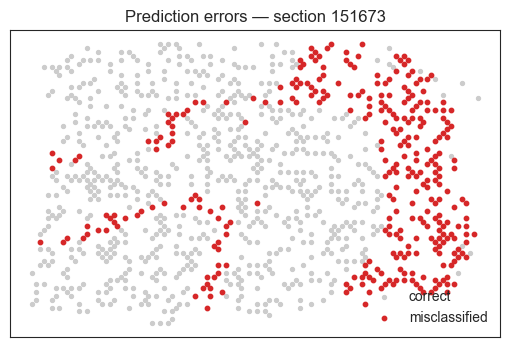

31.0% of spots misclassified in this section.
Look at where the red spots sit: do the errors cluster at region boundaries?


In [37]:
# Where does the model get it wrong, spatially?
test_meta = df_meta[test_mask].copy()
test_meta["predicted"] = le.inverse_transform(y_pred_early)
test_meta["correct"] = test_meta["predicted"] == test_meta["region"]

secs = test_meta["sample_id"].astype(str).unique()
show_sec = SECTION if SECTION in secs else secs[0]
sec = test_meta[test_meta["sample_id"].astype(str) == show_sec]

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(sec.loc[sec["correct"], "array_col"], sec.loc[sec["correct"], "array_row"],
           s=8, c="#CCCCCC", label="correct")
ax.scatter(sec.loc[~sec["correct"], "array_col"], sec.loc[~sec["correct"], "array_row"],
           s=10, c="#D62728", label="misclassified")
ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Prediction errors — section {show_sec}"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"{(~sec['correct']).mean():.1%} of spots misclassified in this section.")
print("Look at where the red spots sit: do the errors cluster at region boundaries?")

## 10. Late Fusion

**Late fusion** = train a separate model per modality, then combine their *predictions* rather
than their features. This helps when the modalities have very different dimensionality or noise
characteristics, and it lets you weight one modality against the other.

In [38]:
# Train one model per modality, then average their predicted probabilities
rf_gene = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)
rf_flux = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)
rf_gene.fit(X_gene_train, y_train)
rf_flux.fit(X_flux_train, y_train)

p_gene = rf_gene.predict_proba(X_gene_test)
p_flux = rf_flux.predict_proba(X_flux_test)

W = 0.5                                  # <-- weight on the gene model; try 0.3, 0.7, 0.9
y_pred_late = (W * p_gene + (1 - W) * p_flux).argmax(axis=1)

print(f"── Late fusion (weight {W} on genes) ──")
print(f"Accuracy          : {accuracy_score(y_test, y_pred_late):.3f}")
print(f"Balanced accuracy : {balanced_accuracy_score(y_test, y_pred_late):.3f}")

── Late fusion (weight 0.5 on genes) ──
Accuracy          : 0.700
Balanced accuracy : 0.750


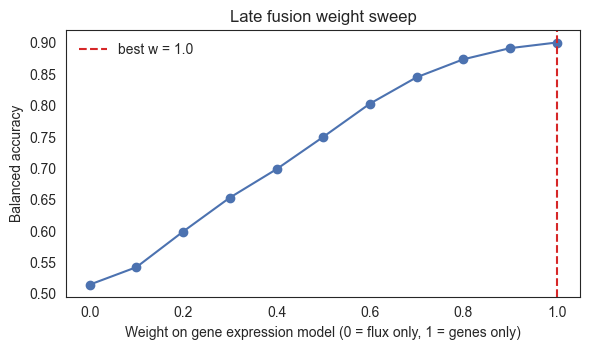

In [39]:
# Sweep the fusion weight to see whether either modality dominates
weights = np.linspace(0, 1, 11)
scores = [balanced_accuracy_score(y_test, (w * p_gene + (1 - w) * p_flux).argmax(1))
          for w in weights]

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(weights, scores, "o-", color="#4C72B0")
best_w = weights[int(np.argmax(scores))]
ax.axvline(best_w, ls="--", c="#D62728", label=f"best w = {best_w:.1f}")
ax.set_xlabel("Weight on gene expression model (0 = flux only, 1 = genes only)")
ax.set_ylabel("Balanced accuracy"); ax.set_title("Late fusion weight sweep")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 11. Summary

In [40]:
summary = pd.DataFrame({
    "Strategy": ["Genes only", "Flux only", "Early fusion", "Late fusion"],
    "Accuracy": [results["Genes only"]["Accuracy"],
                 results["Flux only"]["Accuracy"],
                 results["Early fusion"]["Accuracy"],
                 accuracy_score(y_test, y_pred_late)],
    "Balanced accuracy": [results["Genes only"]["Balanced accuracy"],
                          results["Flux only"]["Balanced accuracy"],
                          results["Early fusion"]["Balanced accuracy"],
                          balanced_accuracy_score(y_test, y_pred_late)],
}).round(3)
print(f"Held-out donor: {TEST_DONOR}\n")
print(summary.to_string(index=False))

Held-out donor: Br8100

    Strategy  Accuracy  Balanced accuracy
  Genes only     0.879              0.901
   Flux only     0.505              0.515
Early fusion     0.730              0.777
 Late fusion     0.700              0.750


### 🔬 YOUR TURN — stretch tasks

Pick whichever interests you:

1. **The full 7-class problem.** Set `y = LabelEncoder().fit_transform(df_meta["layer"])` and rerun. It is much harder — which layers get confused, and does that make anatomical sense?
2. **Change the held-out donor.** Rerun with `TEST_DONOR = "Br5292"` and `"Br5595"`. How stable is your accuracy? What does that say about reporting a single number?
3. **Vary the smoothing.** Try `K_NEIGHBOURS = 0` (no smoothing), 6, and 24. Where does it stop helping, and why might too much smoothing hurt?
4. **Add spatial coordinates as features.** Does `array_row` help? Is that a fair thing to do?

In [ ]:
### YOUR TURN ###
# Your stretch task here:


### 🔬 YOUR TURN — your presentation

Prepare a **10-minute talk** covering:

1. **The question** — what were you predicting, and from what?
2. **The data** — what did EDA show? Anything surprising?
3. **The model** — what did you try, and how did you evaluate it honestly?
4. **The interpretation** — which genes and metabolic modules did SHAP flag, and do they make biological sense?
5. **The caveats** — what would you *not* conclude from this, and what would you check next?

We are not looking for the highest accuracy. We are looking for a defensible pipeline, an honest
evaluation, and an interpretation you can stand behind and discuss.

---

### Two caveats worth discussing

**The fluxes are estimated, not measured.** scFEA infers them *from the same expression matrix*
the gene features come from. So a SHAP result showing a flux module as important is partly
re-reading the transcriptome. This is a real limitation, and noticing it is exactly the habit
this project is meant to build.

**One held-out donor is one number.** With three donors you have three possible splits, and they
do not all give the same answer. A single accuracy figure from a single split is weak evidence —
say so when you present it.

---

## Appendix A — Rebuilding the tables from raw data

You do **not** need this — the three CSV files are provided. This is here so you can see where
they came from, and extend the pipeline to more spots or more genes if you want to.

The raw data are public and need no login:

```python
import urllib.request

SAMPLES = [151507, 151508, 151509, 151510, 151669, 151670,
           151671, 151672, 151673, 151674, 151675, 151676]

# Count matrices (one .h5 per section, ~13 MB each)
for s in SAMPLES:
    urllib.request.urlretrieve(
        f"https://spatial-dlpfc.s3.us-east-2.amazonaws.com/h5/{s}_filtered_feature_bc_matrix.h5",
        f"{s}_filtered_feature_bc_matrix.h5")
    # Spot coordinates
    urllib.request.urlretrieve(
        f"https://raw.githubusercontent.com/LieberInstitute/HumanPilot/master/10X/{s}/tissue_positions_list.txt",
        f"{s}_tissue_positions_list.txt")

# Expert layer annotation for all 47,329 spots
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/LieberInstitute/HumanPilot/master/10X/barcode_level_layer_map.tsv",
    "barcode_level_layer_map.tsv")
```

Processing then follows a standard Scanpy workflow: read each `.h5`, attach the coordinates and
the layer label, concatenate the sections, drop mitochondrial and ribosomal genes, normalise to
10,000 counts per spot, log-transform, and select the top 1,000 highly variable genes with
`batch_key="donor"`.

## Appendix B — How the metabolic fluxes were generated

`dlpfc_flux.csv` was produced with **scFEA**. Again, you do not need to run this, but here is
exactly how it was made.

**Step 1. Install and get scFEA**

```bash
pip install torch magic-impute tqdm
git clone https://github.com/changwn/scFEA.git
```

**Step 2. Prepare the input.** scFEA expects a **genes × cells** matrix of *raw counts* — the
opposite orientation to our expression table — restricted to the metabolic genes it models:

```python
mg = pd.read_csv("scFEA/data/module_gene_m168.csv")
mod_genes = {g for g in mg.iloc[:, 1:].values.ravel() if isinstance(g, str) and g.strip()}
present   = [g for g in sorted(mod_genes) if g in adata.var_names]      # 524 of 663 found
counts    = pd.DataFrame(np.asarray(adata[:, present].layers["counts"].todense()).T,
                         index=present, columns=adata.obs_names)
counts.to_csv("scfea_input_counts.csv")
```

**Step 3. Run scFEA**

```bash
mkdir -p output          # scFEA writes its loss log to a hardcoded ./output/ folder
PYTHONPATH=scFEA/src python scFEA/src/scFEA.py \
    --data_dir scFEA/data \
    --input_dir . \
    --res_dir . \
    --test_file scfea_input_counts.csv \
    --moduleGene_file module_gene_m168.csv \
    --stoichiometry_matrix cmMat_c70_m168.csv \
    --cName_file cName_c70_m168.csv \
    --sc_imputation True \
    --train_epoch 30 \
    --output_flux_file dlpfc_flux.csv
```

Two practical notes from actually running this:

* scFEA writes its loss log to a **hardcoded `./output/` directory** regardless of `--res_dir`. Create it first or the run crashes *after* training finishes.
* scFEA was written for **pandas 1.x**. On pandas 2.x it fails at line 172 of `src/scFEA.py`, where `geneExprDf.append(temp, ...)` must become `pd.concat([geneExprDf, temp], ...)`.

Runtime for the 12,000 spots used here: about **4 minutes on CPU** (30 epochs, plus ~1 minute of
MAGIC imputation).

## References

- **Dataset** — Maynard KR *et al.* (2021) Transcriptome-scale spatial gene expression in the human dorsolateral prefrontal cortex. *Nature Neuroscience* 24:425–436. https://github.com/LieberInstitute/HumanPilot
- **scFEA** — Alghamdi N *et al.* (2021) A graph neural network model to estimate cell-wise metabolic flux using single-cell RNA-seq data. *Genome Research* 31:1867–1884. https://github.com/changwn/scFEA
- **SHAP** — Lundberg SM & Lee S-I (2017) A unified approach to interpreting model predictions. *NeurIPS*. https://github.com/shap/shap
- **Scanpy** — Wolf FA *et al.* (2018) SCANPY: large-scale single-cell gene expression data analysis. *Genome Biology* 19:15.